C:\Users\DELL\AppData\Local\Temp\ipykernel_14788\1018951634.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_summary, x='Channel', y='Amount_NGN', palette='Blues_r')


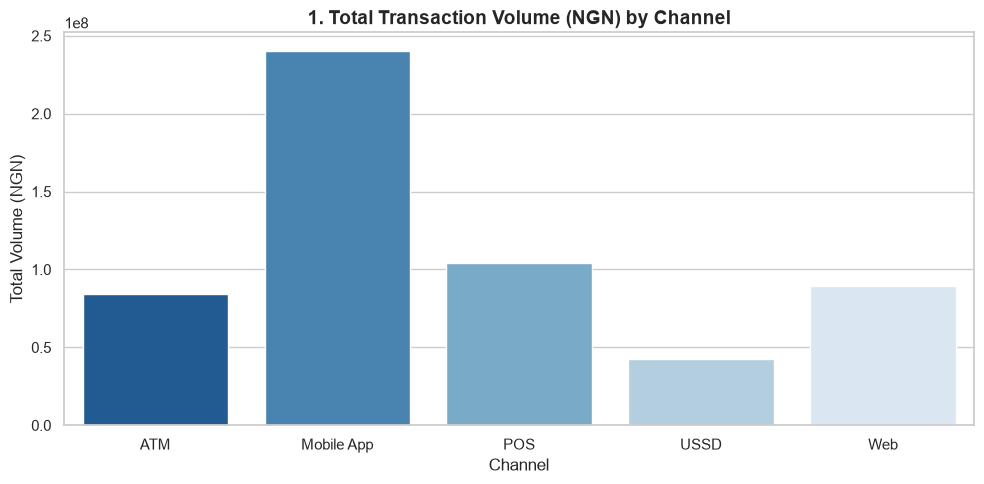

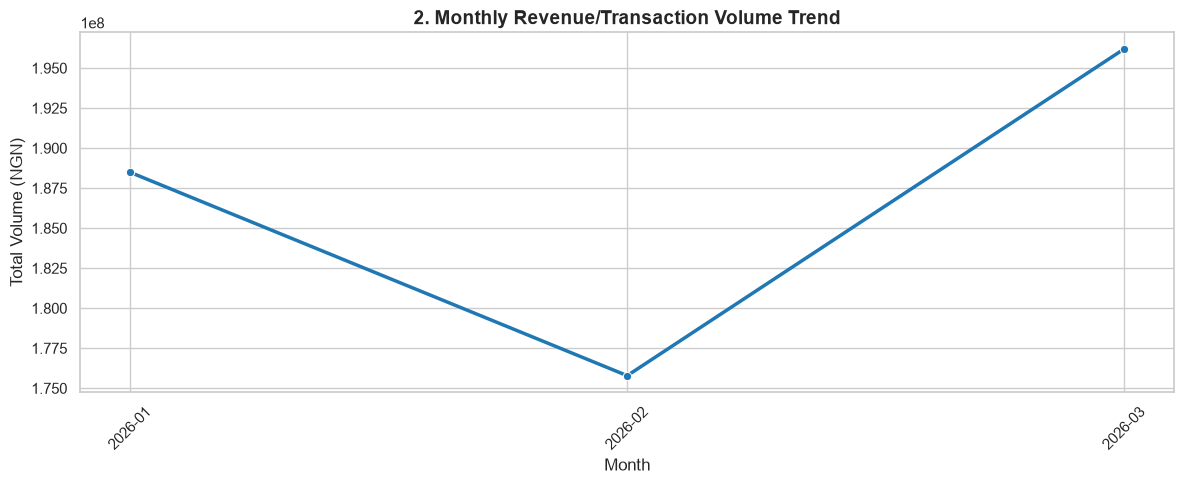

<Figure size 1000x500 with 0 Axes>

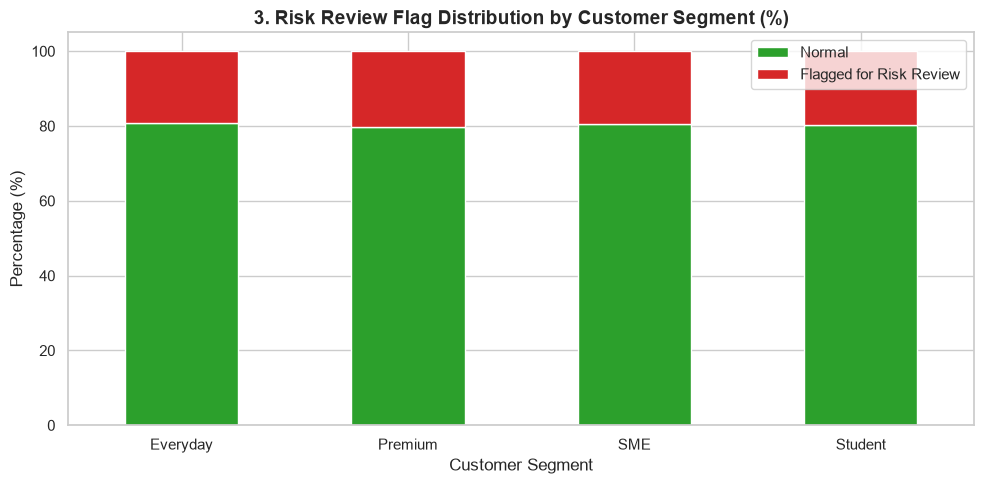

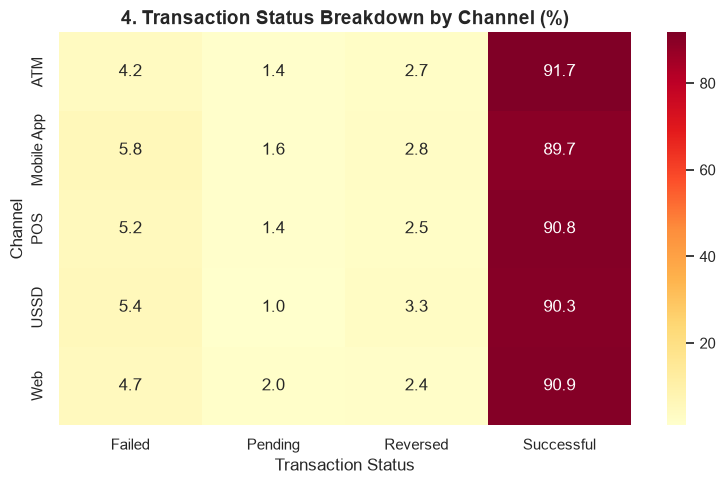

C:\Users\DELL\AppData\Local\Temp\ipykernel_14788\1018951634.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='Account_Type', y='Amount_NGN', palette='Set2')


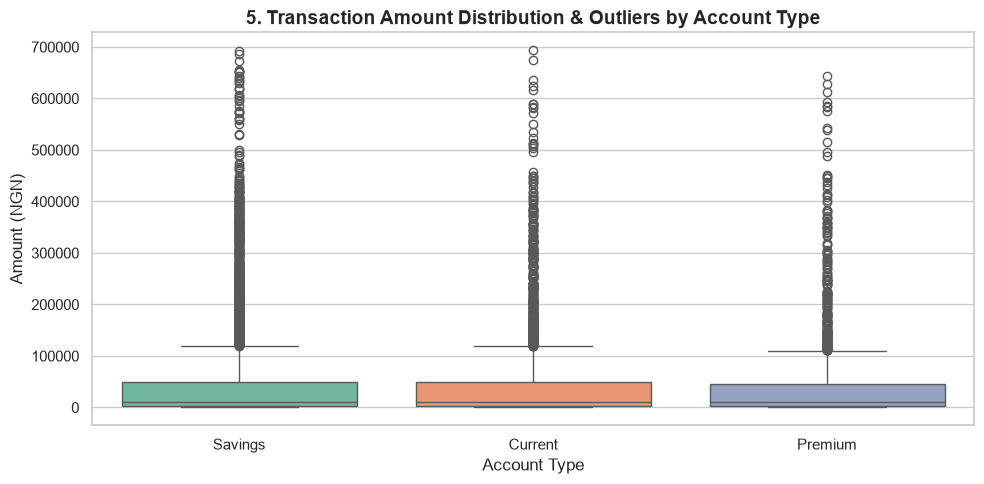

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Datasets
txns_df = pd.read_csv('FINTRUST CUSTOMER DATA.csv')      # Transaction details
customers_df = pd.read_csv('FINTRUST TRANSACTION DATA.csv')  # Customer details

# 2. Merge Datasets on Customer_ID
merged_df = pd.merge(txns_df, customers_df, on='Customer_ID', how='inner')

# Set aesthetic styling
sns.set_theme(style="whitegrid")

# --------------------------------------------------------------------
# VISUALIZATION 1: Total Transaction Volume (NGN) by Channel
# --------------------------------------------------------------------
plt.figure(figsize=(10, 5))
channel_summary = merged_df.groupby('Channel')['Amount_NGN'].sum().reset_index()
sns.barplot(data=channel_summary, x='Channel', y='Amount_NGN', palette='Blues_r')
plt.title('1. Total Transaction Volume (NGN) by Channel', fontsize=14, fontweight='bold')
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Total Volume (NGN)', fontsize=12)
plt.tight_layout()
plt.savefig('fig1_transaction_volume_by_channel.png', dpi=300)
plt.show()

# --------------------------------------------------------------------
# VISUALIZATION 2: Monthly Transaction Trend Analysis
# --------------------------------------------------------------------
merged_df['Transaction_DateTime'] = pd.to_datetime(merged_df['Transaction_DateTime'])
merged_df['YearMonth'] = merged_df['Transaction_DateTime'].dt.to_period('M').astype(str)

monthly_trend = merged_df.groupby('YearMonth')['Amount_NGN'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_trend, x='YearMonth', y='Amount_NGN', marker='o', color='#1f77b4', linewidth=2.5)
plt.title('2. Monthly Revenue/Transaction Volume Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Volume (NGN)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig2_monthly_trend.png', dpi=300)
plt.show()

# --------------------------------------------------------------------
# VISUALIZATION 3: Risk Flag Distribution by Customer Segment
# --------------------------------------------------------------------
plt.figure(figsize=(10, 5))
risk_segment = pd.crosstab(merged_df['Customer_Segment'], merged_df['Risk_Review_Flag'], normalize='index') * 100
risk_segment.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(10, 5))
plt.title('3. Risk Review Flag Distribution by Customer Segment (%)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(['Normal', 'Flagged for Risk Review'], loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig3_risk_by_segment.png', dpi=300)
plt.show()

# --------------------------------------------------------------------
# VISUALIZATION 4: Transaction Status Failure Rate by Channel
# --------------------------------------------------------------------
plt.figure(figsize=(8, 5))
status_channel = pd.crosstab(merged_df['Channel'], merged_df['Transaction_Status'], normalize='index') * 100
sns.heatmap(status_channel, annot=True, fmt=".1f", cmap='YlOrRd', cbar=True)
plt.title('4. Transaction Status Breakdown by Channel (%)', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Status', fontsize=12)
plt.ylabel('Channel', fontsize=12)
plt.tight_layout()
plt.savefig('fig4_status_by_channel_heatmap.png', dpi=300)
plt.show()

# --------------------------------------------------------------------
# VISUALIZATION 5: Amount Distribution by Account Type
# --------------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(data=merged_df, x='Account_Type', y='Amount_NGN', palette='Set2')
plt.title('5. Transaction Amount Distribution & Outliers by Account Type', fontsize=14, fontweight='bold')
plt.xlabel('Account Type', fontsize=12)
plt.ylabel('Amount (NGN)', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_amount_distribution_boxplot.png', dpi=300)
plt.show() 